# Train DenseNet121_FCSSAM On Overall Dataset (Common Pipeline)

TensorFlow notebook for Kaggle GPU/P100.

Dataset path:
`/kaggle/input/datasets/thuanminh1310/datasetspbl4/pbl4_main_aux_datasets`

Classes:
- `normal`
- `pneumonia_only`
- `effusion_only`

Sử dụng cùng bộ dữ liệu `overall` và cùng pipeline xử lý dữ liệu với notebook VGG19 + GAP
để đảm bảo so sánh khách quan.


In [1]:
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

SEED = 42
MODEL_KEY = "densenet121_fcssam"
DISPLAY_NAME = "DenseNet121_FCSSAM_Overall_CommonPipelineV2_256_CaffeNoContrast_EffBoost15_AdamW_Smooth"
CLASS_NAMES = ["normal", "pneumonia_only", "effusion_only"]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

DATASET_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/thuanminh1310/datasetspbl4/pbl4_main_aux_datasets",
    "/kaggle/working/pbl4_main_aux_datasets",
    "/kaggle/input/pbl4-main-aux-datasets",
]

NIH_IMAGE_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/organizations/nih-chest-xrays/data",
    "/kaggle/input/nih-chest-xrays/data",
    "/kaggle/input/chest-xray14/images",
]

EXTERNAL_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray",
    "/kaggle/input/chest-xray-pneumonia/chest_xray",
]

TRAIN_MANIFEST_NAME = "main_train_2_1_1.csv"
VAL_MANIFEST_NAME = "main_val_70_15_15.csv"
TEST_MANIFEST_NAME = "main_test_70_15_15.csv"

IMAGE_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 22
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.03
EFFUSION_BOOST = 1.5
PATIENCE = 6
DROPOUT_RATE = 0.0

OUTPUT_DIR = Path("/kaggle/working/train_densenet121_fcssam_overall_common_pipeline_v2_256_caffe_effboost15_adamw_smooth_threshold")
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models" / MODEL_KEY
PREDICTION_DIR = OUTPUT_DIR / "predictions"
for directory in [OUTPUT_DIR, ARTIFACT_DIR, FIGURE_DIR, MODEL_DIR, PREDICTION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Configuration")
print(f"- model: {MODEL_KEY}")
print(f"- classes: {CLASS_NAMES}")
print(f"- image_size: {IMAGE_SIZE}")
print(f"- batch_size: {BATCH_SIZE}")
print(f"- output_dir: {OUTPUT_DIR}")


2026-06-09 05:48:04.239478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780984084.458828      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780984084.534636      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780984085.068144      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780984085.068193      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780984085.068196      23 computation_placer.cc:177] computation placer alr

Configuration
- model: densenet121_fcssam
- classes: ['normal', 'pneumonia_only', 'effusion_only']
- image_size: 256
- batch_size: 16
- output_dir: /kaggle/working/train_densenet121_fcssam_overall_common_pipeline_v2_256_caffe_effboost15_adamw_smooth_threshold


In [2]:
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


seed_everything(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print("Could not set memory growth:", exc)

try:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())
except Exception as exc:
    print("Mixed precision not enabled:", exc)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [3]:
VALID_IMAGE_EXTS = {".png", ".jpg", ".jpeg"}
IMAGE_INDEX_CACHE = {}


def build_image_index(search_root):
    image_map = {}
    duplicate_names = set()
    image_paths = sorted(path for path in search_root.rglob("*") if path.suffix.lower() in VALID_IMAGE_EXTS)
    for image_path in image_paths:
        image_name = image_path.name
        if image_name in image_map and image_map[image_name] != str(image_path):
            duplicate_names.add(image_name)
            continue
        image_map.setdefault(image_name, str(image_path))
    return image_map, duplicate_names


def get_cached_image_index(search_root):
    key = str(search_root)
    if key not in IMAGE_INDEX_CACHE:
        IMAGE_INDEX_CACHE[key] = build_image_index(search_root)
    return IMAGE_INDEX_CACHE[key]


def remap_relative_to_root(original_path, target_root, anchor_name):
    path_obj = Path(str(original_path))
    if path_obj.exists():
        return str(path_obj)
    parts = list(path_obj.parts)
    if anchor_name in parts:
        anchor_idx = parts.index(anchor_name)
        relative_parts = parts[anchor_idx + 1:]
        candidate = target_root.joinpath(*relative_parts)
        if candidate.exists():
            return str(candidate)
    return str(original_path)


def resolve_manifest_paths(frame, nih_root, external_root):
    df = frame.copy()
    if "resolved_path" not in df.columns:
        raise KeyError("Manifest must contain 'resolved_path'.")

    df["resolved_path"] = df["resolved_path"].astype(str)
    df["resolved_path"] = np.where(
        df["source"].eq("nih"),
        df["resolved_path"].map(lambda p: remap_relative_to_root(p, nih_root, "data")),
        df["resolved_path"],
    )
    df["resolved_path"] = np.where(
        df["source"].eq("chest_xray_pneumonia"),
        df["resolved_path"].map(lambda p: remap_relative_to_root(p, external_root, "chest_xray")),
        df["resolved_path"],
    )

    exists_mask = df["resolved_path"].map(lambda x: Path(str(x)).exists())
    if exists_mask.all():
        df["image_path"] = df["resolved_path"]
        return df

    if df.loc[~exists_mask, "source"].eq("nih").any():
        nih_map, _ = get_cached_image_index(nih_root)
        missing_mask = df["source"].eq("nih") & ~exists_mask
        df.loc[missing_mask, "resolved_path"] = df.loc[missing_mask, "resolved_path"].map(
            lambda p: nih_map.get(Path(str(p)).name, str(p))
        )

    exists_mask = df["resolved_path"].map(lambda x: Path(str(x)).exists())
    if df.loc[~exists_mask, "source"].eq("chest_xray_pneumonia").any():
        ext_map, _ = get_cached_image_index(external_root)
        missing_mask = df["source"].eq("chest_xray_pneumonia") & ~exists_mask
        df.loc[missing_mask, "resolved_path"] = df.loc[missing_mask, "resolved_path"].map(
            lambda p: ext_map.get(Path(str(p)).name, str(p))
        )

    final_missing = ~df["resolved_path"].map(lambda x: Path(str(x)).exists())
    if final_missing.any():
        examples = df.loc[final_missing, ["source", "resolved_path"]].head(5).to_dict("records")
        raise FileNotFoundError(f"Could not resolve some image paths. Examples: {examples}")

    df["image_path"] = df["resolved_path"]
    return df


def find_existing_dir(candidates):
    for candidate in candidates:
        candidate_path = Path(candidate)
        if candidate_path.exists():
            return candidate_path
    raise FileNotFoundError(f"Could not find any valid directory from: {candidates}")


def load_manifest(manifest_path, class_to_index, nih_root, external_root):
    df = pd.read_csv(manifest_path)
    if "class_index" not in df.columns:
        df["class_index"] = df["class_name"].map(class_to_index)
    if df["class_index"].isna().any():
        bad_classes = sorted(df.loc[df["class_index"].isna(), "class_name"].dropna().unique().tolist())
        raise ValueError(f"Unknown class names found: {bad_classes}")
    df["class_index"] = df["class_index"].astype(int)
    df = resolve_manifest_paths(df, nih_root, external_root)
    return df.reset_index(drop=True)


def summarize_counts(df, class_names, split_name):
    summary_df = df["class_name"].value_counts().reindex(class_names, fill_value=0).rename_axis("class_name").reset_index(name="samples")
    summary_df["split"] = split_name
    return summary_df


DATASET_ROOT = find_existing_dir(DATASET_ROOT_CANDIDATES)
MANIFEST_DIR = DATASET_ROOT / "manifests"
NIH_IMAGE_ROOT = find_existing_dir(NIH_IMAGE_ROOT_CANDIDATES)
EXTERNAL_ROOT = find_existing_dir(EXTERNAL_ROOT_CANDIDATES)

print(f"DATASET_ROOT: {DATASET_ROOT}")
print(f"MANIFEST_DIR: {MANIFEST_DIR}")
print(f"NIH_IMAGE_ROOT: {NIH_IMAGE_ROOT}")
print(f"EXTERNAL_ROOT: {EXTERNAL_ROOT}")

train_df = load_manifest(MANIFEST_DIR / TRAIN_MANIFEST_NAME, CLASS_TO_INDEX, NIH_IMAGE_ROOT, EXTERNAL_ROOT)
val_df = load_manifest(MANIFEST_DIR / VAL_MANIFEST_NAME, CLASS_TO_INDEX, NIH_IMAGE_ROOT, EXTERNAL_ROOT)
test_df = load_manifest(MANIFEST_DIR / TEST_MANIFEST_NAME, CLASS_TO_INDEX, NIH_IMAGE_ROOT, EXTERNAL_ROOT)

counts_df = pd.concat([
    summarize_counts(train_df, CLASS_NAMES, "train"),
    summarize_counts(val_df, CLASS_NAMES, "val"),
    summarize_counts(test_df, CLASS_NAMES, "test"),
], ignore_index=True)
counts_df.to_csv(ARTIFACT_DIR / "overall_dataset_counts.csv", index=False)

display(counts_df)
display(train_df.head(5))


DATASET_ROOT: /kaggle/input/datasets/thuanminh1310/datasetspbl4/pbl4_main_aux_datasets
MANIFEST_DIR: /kaggle/input/datasets/thuanminh1310/datasetspbl4/pbl4_main_aux_datasets/manifests
NIH_IMAGE_ROOT: /kaggle/input/datasets/organizations/nih-chest-xrays/data
EXTERNAL_ROOT: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


,class_name,samples,split
0,normal,6190,train
1,pneumonia_only,3095,train
2,effusion_only,3095,train
3,normal,1895,val
4,pneumonia_only,406,val
5,effusion_only,406,val
6,normal,1699,test
7,pneumonia_only,364,test
8,effusion_only,364,test


,sample_id,source,original_split,resolved_path,patient_id,patient_group_id,view_position,finding_labels_raw,class_name,selected_clean,split,class_index,image_path
0,nih_00006203_000.png,nih,raw,/kaggle/input/datasets/organizations/nih-chest...,6203,nih_patient_6203,PA,No Finding,normal,True,train,0,/kaggle/input/datasets/organizations/nih-chest...
1,external_train_PNEUMONIA_person796_bacteria_27...,chest_xray_pneumonia,train,/kaggle/input/datasets/paultimothymooney/chest...,person796_bacteria_2702,external_person796,UNK,PNEUMONIA,pneumonia_only,True,train,1,/kaggle/input/datasets/paultimothymooney/chest...
2,nih_00017981_000.png,nih,raw,/kaggle/input/datasets/organizations/nih-chest...,17981,nih_patient_17981,PA,No Finding,normal,True,train,0,/kaggle/input/datasets/organizations/nih-chest...
3,nih_00006738_003.png,nih,raw,/kaggle/input/datasets/organizations/nih-chest...,6738,nih_patient_6738,PA,No Finding,normal,True,train,0,/kaggle/input/datasets/organizations/nih-chest...
4,external_train_PNEUMONIA_person298_bacteria_14...,chest_xray_pneumonia,train,/kaggle/input/datasets/paultimothymooney/chest...,person298_bacteria_1408,external_person298,UNK,PNEUMONIA,pneumonia_only,True,train,1,/kaggle/input/datasets/paultimothymooney/chest...


In [4]:
train_class_counts = train_df["class_index"].value_counts().sort_index().reindex(range(len(CLASS_NAMES)), fill_value=0).astype(float)
base_class_weights = len(train_df) / (len(CLASS_NAMES) * train_class_counts.values)
base_class_weights = base_class_weights / base_class_weights.mean()
base_class_weights[CLASS_TO_INDEX["effusion_only"]] *= EFFUSION_BOOST
base_class_weights = base_class_weights / base_class_weights.mean()

class_weight_df = pd.DataFrame({
    "class_name": CLASS_NAMES,
    "train_count": train_class_counts.values.astype(int),
    "class_weight": base_class_weights,
})
class_weight_df.to_csv(ARTIFACT_DIR / "class_weights.csv", index=False)
display(class_weight_df)


,class_name,train_count,class_weight
0,normal,6190,0.5
1,pneumonia_only,3095,1.0
2,effusion_only,3095,1.5


In [5]:
AUTOTUNE = tf.data.AUTOTUNE


def build_augmenter():
    return tf.keras.Sequential([
        tf.keras.layers.RandomTranslation(0.015, 0.015),
        tf.keras.layers.RandomZoom(0.03, 0.03),
        tf.keras.layers.RandomFlip("horizontal"),
    ], name="xray_augmenter_effusion_heavy_nih")


AUGMENTER = build_augmenter()


def enhance_xray_contrast(image):
    image = tf.cast(image, tf.float32) / 255.0
    image_min = tf.reduce_min(image, axis=[0, 1, 2], keepdims=True)
    image_max = tf.reduce_max(image, axis=[0, 1, 2], keepdims=True)
    image = (image - image_min) / tf.maximum(image_max - image_min, 1e-6)
    image = tf.image.adjust_gamma(image, gamma=0.95)
    return tf.clip_by_value(image * 255.0, 0.0, 255.0)


def common_preprocess_input(image):
    image = tf.cast(image, tf.float32)
    image = image[..., ::-1]  # RGB -> BGR
    mean = tf.constant([103.939, 116.779, 123.680], dtype=tf.float32)
    return image - mean


def decode_resize_preprocess(path, label, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE], method=tf.image.ResizeMethod.BILINEAR)
    image = enhance_xray_contrast(image)
    image = tf.image.grayscale_to_rgb(image)
    if training:
        image = AUGMENTER(image, training=True)
    image = common_preprocess_input(image)
    return image, tf.cast(label, tf.int32)


def make_dataset(df, batch_size, training=False):
    paths = df["resolved_path"].astype(str).values
    labels = df["class_index"].astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: decode_resize_preprocess(x, y, training=training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    return ds.prefetch(AUTOTUNE)


train_ds = make_dataset(train_df, BATCH_SIZE, training=True)
val_ds = make_dataset(val_df, BATCH_SIZE, training=False)
test_ds = make_dataset(test_df, BATCH_SIZE, training=False)

sample_images, sample_labels = next(iter(train_ds.take(1)))
print("sample batch:", sample_images.shape, sample_labels.shape, sample_images.dtype)


I0000 00:00:1780984163.688292      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


sample batch: (16, 256, 256, 3) (16,) <dtype: 'float32'>


In [6]:
layers = tf.keras.layers


@tf.keras.utils.register_keras_serializable()
class ChannelMean(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)


@tf.keras.utils.register_keras_serializable()
class ChannelMax(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)


@tf.keras.utils.register_keras_serializable()
class FuzzyChannelSelection(layers.Layer):
    def __init__(self, keep_ratio=0.80, **kwargs):
        super().__init__(**kwargs)
        self.keep_ratio = keep_ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.keep_channels = max(1, int(np.ceil(channels * self.keep_ratio)))
        self.alpha = self.add_weight(
            name="alpha",
            shape=(channels,),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.05, maxval=0.05),
            trainable=True,
        )
        self.richards_A = self.add_weight(name="richards_A", shape=(), initializer=tf.keras.initializers.Constant(0.541324854612918), trainable=True)
        self.richards_Q = self.add_weight(name="richards_Q", shape=(), initializer=tf.keras.initializers.Constant(0.541324854612918), trainable=True)
        self.richards_mu = self.add_weight(name="richards_mu", shape=(), initializer="zeros", trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        A = tf.nn.softplus(self.richards_A) + 1e-6
        Q = tf.nn.softplus(self.richards_Q) + 1e-6
        scores = 1.0 / (1.0 + tf.exp(A - Q * (self.alpha - self.richards_mu)))
        topk = tf.math.top_k(scores, k=self.keep_channels, sorted=True)
        selected = tf.gather(inputs, topk.indices, axis=-1)
        selected_scores = tf.reshape(topk.values, [1, 1, 1, self.keep_channels])
        return selected * selected_scores

    def get_config(self):
        config = super().get_config()
        config.update({"keep_ratio": self.keep_ratio})
        return config


def create_channel_attention_mask(feature_map, ratio=8, prefix="cam"):
    channels = int(feature_map.shape[-1])
    reduced_channels = max(channels // ratio, 8)
    shared_dense_1 = layers.Dense(reduced_channels, activation="relu", use_bias=False, name=f"{prefix}_dense1")
    shared_dense_2 = layers.Dense(channels, use_bias=False, name=f"{prefix}_dense2")
    avg_pool = shared_dense_2(shared_dense_1(layers.GlobalAveragePooling2D(name=f"{prefix}_gap")(feature_map)))
    max_pool = shared_dense_2(shared_dense_1(layers.GlobalMaxPooling2D(name=f"{prefix}_gmp")(feature_map)))
    attention = layers.Add(name=f"{prefix}_add")([avg_pool, max_pool])
    attention = layers.Activation("sigmoid", name=f"{prefix}_sigmoid")(attention)
    return layers.Reshape((1, 1, channels), name=f"{prefix}_reshape")(attention)


def apply_sc_layers(feature_map, channels, prefix):
    x = layers.SeparableConv2D(channels, 1, padding="same", depthwise_initializer="he_normal", pointwise_initializer="he_normal", name=f"{prefix}_sc1")(feature_map)
    x = layers.SeparableConv2D(channels, 3, padding="same", depthwise_initializer="he_normal", pointwise_initializer="he_normal", name=f"{prefix}_sc2")(x)
    x = layers.BatchNormalization(name=f"{prefix}_bn")(x)
    return layers.ReLU(name=f"{prefix}_relu")(x)


def create_spatial_attention_branch(feature_map, cam_mask, pool_mode, prefix):
    channels = int(feature_map.shape[-1])
    sc_features = apply_sc_layers(feature_map, channels, prefix)
    channel_specific = layers.Multiply(name=f"{prefix}_channel_mul")([sc_features, cam_mask])
    if pool_mode == "avg":
        pooled = ChannelMean(name=f"{prefix}_pool")(channel_specific)
    elif pool_mode == "max":
        pooled = ChannelMax(name=f"{prefix}_pool")(channel_specific)
    else:
        raise ValueError(f"Unsupported pool_mode: {pool_mode}")
    spatial_attention = layers.Conv2D(1, 7, padding="same", activation="sigmoid", kernel_initializer="he_normal", name=f"{prefix}_spatial_conv")(pooled)
    return layers.Multiply(name=f"{prefix}_spatial_mul")([channel_specific, spatial_attention])


def create_fcssam_module(feature_map, attention_ratio=8, keep_ratio=0.80, prefix="fcssam"):
    cam_mask = create_channel_attention_mask(feature_map, ratio=attention_ratio, prefix=f"{prefix}_cam")
    sam_avg = create_spatial_attention_branch(feature_map, cam_mask, pool_mode="avg", prefix=f"{prefix}_samavg")
    sam_max = create_spatial_attention_branch(feature_map, cam_mask, pool_mode="max", prefix=f"{prefix}_sammax")
    concat_features = layers.Concatenate(name=f"{prefix}_concat")([sam_avg, sam_max])
    selected_features = FuzzyChannelSelection(keep_ratio=keep_ratio, name=f"{prefix}_select")(concat_features)
    return selected_features


def build_vgg19(input_shape):
    inputs = layers.Input(shape=input_shape, name="image")
    backbone = tf.keras.applications.VGG19(include_top=False, weights="imagenet", input_tensor=inputs)
    x = layers.GlobalAveragePooling2D(name="vgg_gap")(backbone.output)
    x = layers.Dropout(DROPOUT_RATE, name="vgg_dropout")(x)
    x = layers.Dense(256, activation="relu", name="vgg_dense_256")(x)
    x = layers.Dropout(DROPOUT_RATE, name="vgg_dropout_2")(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", dtype="float32", name="class_probs")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="vgg19_effusion_heavy_nih")


def build_densenet121_fcssam(input_shape):
    inputs = layers.Input(shape=input_shape, name="image")
    backbone = tf.keras.applications.DenseNet121(include_top=False, weights="imagenet", input_tensor=inputs)
    fcssam_output = create_fcssam_module(backbone.output, attention_ratio=8, keep_ratio=0.80, prefix="overall_fcssam")
    x = layers.GlobalAveragePooling2D(name="densenet_gap")(fcssam_output)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", dtype="float32", name="class_probs")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="densenet121_fcssam_effusion_heavy_nih")


if MODEL_KEY == "vgg19":
    model = build_vgg19((IMAGE_SIZE, IMAGE_SIZE, 3))
elif MODEL_KEY == "densenet121_fcssam":
    model = build_densenet121_fcssam((IMAGE_SIZE, IMAGE_SIZE, 3))
else:
    raise ValueError(f"Unsupported MODEL_KEY: {MODEL_KEY}")

model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "densenet121_fcssam_effusion_heavy_nih"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ image[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

 Total params: 11,533,791 (44.00 MB)

 Trainable params: 11,446,047 (43.66 MB)

 Non-trainable params: 87,744 (342.75 KB)

In [7]:
def build_weighted_smoothed_sparse_categorical_crossentropy(class_weights, label_smoothing=0.03):
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    num_classes = tf.constant(len(class_weights), dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_one_hot = tf.one_hot(y_true_int, depth=len(class_weights), dtype=tf.float32)
        if label_smoothing > 0:
            smooth_pos = 1.0 - label_smoothing
            smooth_neg = label_smoothing / (num_classes - 1.0)
            y_true_one_hot = y_true_one_hot * smooth_pos + (1.0 - y_true_one_hot) * smooth_neg
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0 - 1e-7)
        per_sample_loss = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)
        sample_weights = tf.gather(class_weights_tensor, y_true_int)
        return tf.reduce_mean(per_sample_loss * sample_weights)

    return loss_fn


try:
    optimizer = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
except Exception:
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=build_weighted_smoothed_sparse_categorical_crossentropy(base_class_weights, LABEL_SMOOTHING),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_DIR / "best.keras", monitor="val_loss", save_best_only=True, mode="min"),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, mode="min"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, mode="min"),
    tf.keras.callbacks.CSVLogger(MODEL_DIR / "history.csv"),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_DIR / "final.keras")
pd.DataFrame(history.history).to_csv(MODEL_DIR / "history_final.csv", index=False)


Epoch 1/22


I0000 00:00:1780984242.524325      65 service.cc:152] XLA service 0x7ef50c063c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780984242.524379      65 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780984257.593057      65 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780984477.674232      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


774/774 ━━━━━━━━━━━━━━━━━━━━ 824s 665ms/step - accuracy: 0.3888 - loss: 0.7864 - val_accuracy: 0.3151 - val_loss: 0.6495 - learning_rate: 5.0000e-05
Epoch 2/22
774/774 ━━━━━━━━━━━━━━━━━━━━ 228s 294ms/step - accuracy: 0.6794 - loss: 0.6000 - val_accuracy: 0.8149 - val_loss: 0.4234 - learning_rate: 5.0000e-05
Epoch 3/22
774/774 ━━━━━━━━━━━━━━━━━━━━ 227s 294ms/step - accuracy: 0.8498 - loss: 0.4223 - val_accuracy: 0.8201 - val_loss: 0.3628 - learning_rate: 5.0000e-05
Epoch 4/22
774/774 ━━━━━━━━━━━━━━━━━━━━ 228s 294ms/step - accuracy: 0.8678 - loss: 0.3392 - val_accuracy: 0.7972 - val_loss: 0.3520 - learning_rate: 5.0000e-05
Epoch 5/22
774/774 ━━━━━━━━━━━━━━━━━━━━ 228s 295ms/step - accuracy: 0.8826 - loss: 0.3160 - val_accuracy: 0.8467 - val_loss: 0.3306 - learning_rate: 5.0000e-05
Epoch 6/22
774/774 ━━━━━━━━━━━━━━━━━━━━ 228s 294ms/step - accuracy: 0.8956 - loss: 0.2989 - val_accuracy: 0.8482 - val_loss: 0.3306 - learning_rate: 5.0000e-05
Epoch 7/22
774/774 ━━━━━━━━━━━━━━━━━━━━ 224s 290ms/

170/170 ━━━━━━━━━━━━━━━━━━━━ 47s 195ms/step
152/152 ━━━━━━━━━━━━━━━━━━━━ 35s 230ms/step
Best effusion threshold: 0.79


,threshold,accuracy,macro_f1,weighted_f1,effusion_precision,effusion_recall,effusion_f1,normal_precision,normal_recall,normal_f1,effusion_pred_count
49,0.79,0.881419,0.841522,0.882237,0.635071,0.660099,0.647343,0.918704,0.912401,0.915541,422
42,0.72,0.870336,0.838036,0.875143,0.583004,0.726601,0.646930,0.929922,0.882322,0.905497,506
41,0.71,0.869228,0.837513,0.874362,0.578947,0.731527,0.646355,0.930765,0.879683,0.904504,513
48,0.78,0.879941,0.840638,0.881157,0.627907,0.665025,0.645933,0.919424,0.909235,0.914301,430
43,0.73,0.870706,0.837644,0.875214,0.585170,0.719212,0.645304,0.928532,0.884433,0.905946,499
47,0.77,0.877724,0.839590,0.879631,0.617117,0.674877,0.644706,0.920968,0.903958,0.912383,444
34,0.64,0.859993,0.833958,0.868022,0.548443,0.780788,0.644309,0.939745,0.855937,0.895885,578
20,0.50,0.849280,0.830374,0.860592,0.520486,0.844828,0.644131,0.952584,0.826913,0.885311,659
45,0.75,0.874030,0.838203,0.877195,0.600000,0.694581,0.643836,0.924209,0.894459,0.909091,470
29,0.59,0.855929,0.832432,0.865188,0.537068,0.802956,0.643633,0.944019,0.845383,0.891982,607


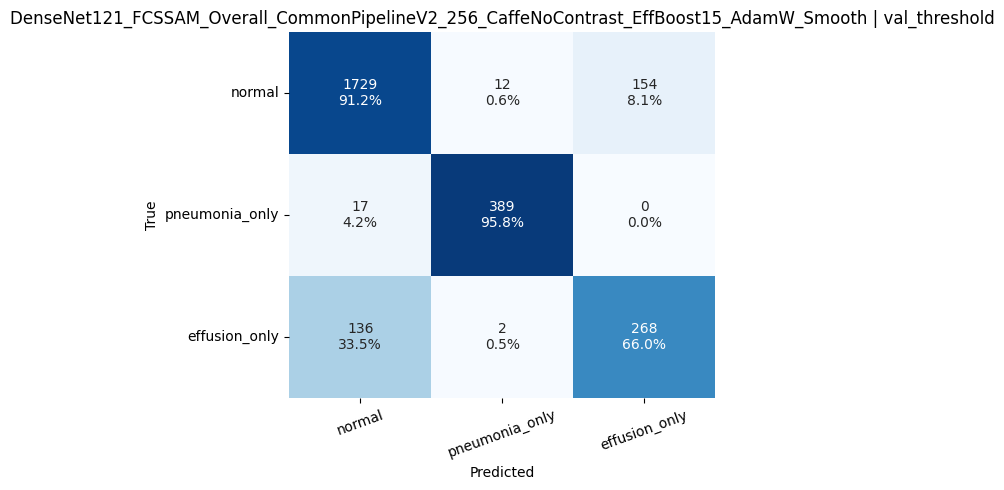

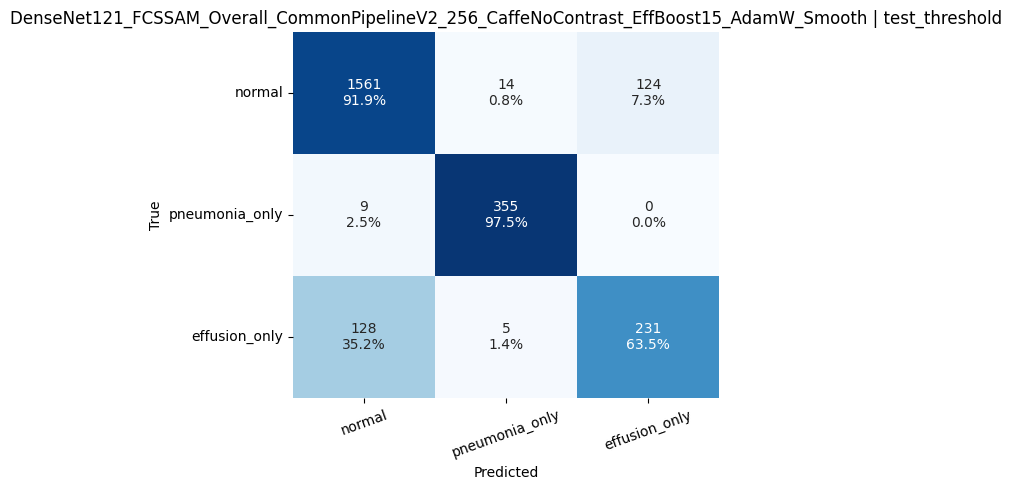

,model_key,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_auc_ovr,effusion_threshold
0,densenet121_fcssam,val_argmax,0.848171,0.812229,0.877385,0.829741,0.859853,0.951288,NaN
1,densenet121_fcssam,test_argmax,0.854553,0.815617,0.881814,0.835468,0.865237,0.953359,NaN
2,densenet121_fcssam,val_threshold,0.881419,0.839678,0.843543,0.841522,0.882237,0.951288,0.79
3,densenet121_fcssam,test_threshold,0.884631,0.839740,0.842889,0.841222,0.884030,0.953359,0.79


,model_key,split,class_name,precision,recall,f1,support,auc_ovr,effusion_threshold
0,densenet121_fcssam,val_argmax,normal,0.954184,0.824274,0.884485,1895,0.938756,NaN
1,densenet121_fcssam,val_argmax,pneumonia_only,0.965261,0.958128,0.961681,406,0.997859,NaN
2,densenet121_fcssam,val_argmax,effusion_only,0.517241,0.849754,0.643057,406,0.917250,NaN
3,densenet121_fcssam,test_argmax,normal,0.955405,0.832254,0.889588,1699,0.944381,NaN
4,densenet121_fcssam,test_argmax,pneumonia_only,0.964674,0.975275,0.969945,364,0.999373,NaN
5,densenet121_fcssam,test_argmax,effusion_only,0.526770,0.837912,0.646872,364,0.916323,NaN
6,densenet121_fcssam,val_threshold,normal,0.918704,0.912401,0.915541,1895,0.938756,0.79
7,densenet121_fcssam,val_threshold,pneumonia_only,0.965261,0.958128,0.961681,406,0.997859,0.79
8,densenet121_fcssam,val_threshold,effusion_only,0.635071,0.660099,0.647343,406,0.917250,0.79
9,densenet121_fcssam,test_threshold,normal,0.919317,0.918776,0.919046,1699,0.944381,0.79


Saved artifacts to: /kaggle/working/train_densenet121_fcssam_overall_common_pipeline_v2_256_caffe_effboost15_adamw_smooth_threshold/artifacts


In [8]:
def predict_probs(model_obj, ds):
    return model_obj.predict(ds, verbose=1).astype(np.float32)


def predict_argmax(probs):
    return np.argmax(probs, axis=1).astype(np.int32)


def predict_with_effusion_threshold(probs, threshold):
    effusion_index = CLASS_TO_INDEX["effusion_only"]
    non_effusion_probs = probs.copy()
    non_effusion_probs[:, effusion_index] = -np.inf
    best_non_effusion = np.argmax(non_effusion_probs, axis=1).astype(np.int32)
    return np.where(probs[:, effusion_index] >= threshold, effusion_index, best_non_effusion).astype(np.int32)


def compute_per_class_auc(y_true, probs):
    auc_map = {}
    for idx, class_name in enumerate(CLASS_NAMES):
        binary_true = (y_true == idx).astype(int)
        if len(np.unique(binary_true)) < 2:
            auc_map[class_name] = np.nan
        else:
            auc_map[class_name] = roc_auc_score(binary_true, probs[:, idx])
    return auc_map


def evaluate_split(y_true, probs, y_pred, split_name):
    auc_map = compute_per_class_auc(y_true, probs)
    class_report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    class_rows = []
    for class_name in CLASS_NAMES:
        row = class_report[class_name]
        class_rows.append({
            "model_key": MODEL_KEY,
            "split": split_name,
            "class_name": class_name,
            "precision": float(row["precision"]),
            "recall": float(row["recall"]),
            "f1": float(row["f1-score"]),
            "support": int(row["support"]),
            "auc_ovr": float(auc_map[class_name]) if not np.isnan(auc_map[class_name]) else np.nan,
        })
    summary = {
        "model_key": MODEL_KEY,
        "split": split_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "macro_auc_ovr": float(np.nanmean(list(auc_map.values()))),
    }
    return pd.DataFrame([summary]), pd.DataFrame(class_rows)


def tune_effusion_threshold(y_true, probs):
    rows = []
    effusion_index = CLASS_TO_INDEX["effusion_only"]
    for threshold in np.round(np.arange(0.30, 0.901, 0.01), 2):
        y_pred = predict_with_effusion_threshold(probs, threshold)
        summary_df, class_df = evaluate_split(y_true, probs, y_pred, "val_threshold_search")
        effusion_row = class_df.loc[class_df["class_name"] == "effusion_only"].iloc[0]
        normal_row = class_df.loc[class_df["class_name"] == "normal"].iloc[0]
        summary_row = summary_df.iloc[0]
        rows.append({
            "threshold": float(threshold),
            "accuracy": float(summary_row["accuracy"]),
            "macro_f1": float(summary_row["macro_f1"]),
            "weighted_f1": float(summary_row["weighted_f1"]),
            "effusion_precision": float(effusion_row["precision"]),
            "effusion_recall": float(effusion_row["recall"]),
            "effusion_f1": float(effusion_row["f1"]),
            "normal_precision": float(normal_row["precision"]),
            "normal_recall": float(normal_row["recall"]),
            "normal_f1": float(normal_row["f1"]),
            "effusion_pred_count": int(np.sum(y_pred == effusion_index)),
        })
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(
        ["effusion_f1", "macro_f1", "effusion_precision", "normal_recall", "accuracy"],
        ascending=[False, False, False, False, False],
    ).iloc[0]
    return float(best_row["threshold"]), threshold_df


def save_prediction_frame(df, probs, y_pred, split_name, threshold):
    pred_df = df[[column for column in ["sample_id", "source", "resolved_path", "class_name", "class_index", "finding_labels_raw"] if column in df.columns]].copy()
    pred_df["pred_class_index"] = y_pred
    pred_df["pred_class_name"] = [CLASS_NAMES[idx] for idx in y_pred]
    pred_df["effusion_threshold"] = threshold
    for idx, class_name in enumerate(CLASS_NAMES):
        pred_df[f"prob_{class_name}"] = probs[:, idx]
    pred_df.to_csv(PREDICTION_DIR / f"{MODEL_KEY}_{split_name}_predictions.csv", index=False)
    return pred_df


def plot_confusion(y_true, y_pred, split_name):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    annotations = np.empty_like(cm, dtype=object)
    for row_idx in range(cm.shape[0]):
        for col_idx in range(cm.shape[1]):
            annotations[row_idx, col_idx] = f"{cm[row_idx, col_idx]}\n{cm_norm[row_idx, col_idx]:.1%}"
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=annotations, fmt="", cmap="Blues", vmin=0.0, vmax=1.0, cbar=False, ax=ax)
    ax.set_title(f"{DISPLAY_NAME} | {split_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticklabels(CLASS_NAMES, rotation=20)
    ax.set_yticklabels(CLASS_NAMES, rotation=0)
    plt.tight_layout()
    path = FIGURE_DIR / f"{MODEL_KEY}_{split_name}_confusion.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    return path


val_probs = predict_probs(model, val_ds)
test_probs = predict_probs(model, test_ds)
y_val_true = val_df["class_index"].astype(np.int32).values
y_test_true = test_df["class_index"].astype(np.int32).values

y_val_argmax = predict_argmax(val_probs)
y_test_argmax = predict_argmax(test_probs)
argmax_val_summary_df, argmax_val_class_df = evaluate_split(y_val_true, val_probs, y_val_argmax, "val_argmax")
argmax_test_summary_df, argmax_test_class_df = evaluate_split(y_test_true, test_probs, y_test_argmax, "test_argmax")

best_effusion_threshold, threshold_df = tune_effusion_threshold(y_val_true, val_probs)
threshold_df.to_csv(ARTIFACT_DIR / f"{MODEL_KEY}_effusion_threshold_search.csv", index=False)
print(f"Best effusion threshold: {best_effusion_threshold:.2f}")
display(threshold_df.sort_values(["effusion_f1", "macro_f1"], ascending=False).head(15))

y_val_pred = predict_with_effusion_threshold(val_probs, best_effusion_threshold)
y_test_pred = predict_with_effusion_threshold(test_probs, best_effusion_threshold)

val_summary_df, val_class_df = evaluate_split(y_val_true, val_probs, y_val_pred, "val_threshold")
test_summary_df, test_class_df = evaluate_split(y_test_true, test_probs, y_test_pred, "test_threshold")
summary_df = pd.concat([argmax_val_summary_df, argmax_test_summary_df, val_summary_df, test_summary_df], ignore_index=True)
class_df = pd.concat([argmax_val_class_df, argmax_test_class_df, val_class_df, test_class_df], ignore_index=True)

summary_df["effusion_threshold"] = np.where(summary_df["split"].str.contains("threshold"), best_effusion_threshold, np.nan)
class_df["effusion_threshold"] = np.where(class_df["split"].str.contains("threshold"), best_effusion_threshold, np.nan)

summary_df.to_csv(ARTIFACT_DIR / f"{MODEL_KEY}_summary_metrics.csv", index=False)
class_df.to_csv(ARTIFACT_DIR / f"{MODEL_KEY}_class_report.csv", index=False)
save_prediction_frame(val_df, val_probs, y_val_pred, "val_threshold", best_effusion_threshold)
save_prediction_frame(test_df, test_probs, y_test_pred, "test_threshold", best_effusion_threshold)
plot_confusion(y_val_true, y_val_pred, "val_threshold")
plot_confusion(y_test_true, y_test_pred, "test_threshold")

display(summary_df)
display(class_df)
print("Saved artifacts to:", ARTIFACT_DIR)
